In [2]:
import matplotlib.pyplot as plt
import ODESolve_slow as ODE
import numpy as np
import derivatives as der
import nseabundance as nse
import weakrates as weak
from constants import hbar
import scipy

In [4]:
def a_total_y_tot(eta_final, Q0, a0, np_factor, pn_factor, rhonu):
    p = np.array([2, Q0, a0, np_factor, pn_factor, rhonu])
    
    T0 = 15
    a0 = 1/T0
    t0 = 0
    eta0 = eta_final*(11/4)
    Yp0 = (1+(weak.Npntot(T0,a0))/(weak.Nnptot(T0,a0)) )**(-1)
    Yn0 = 1-Yp0

    y0 = der.depvar(T0, t0, eta0, nse.nse(T0, eta0, Yp0, Yn0))
    dx0=0.001

    N_step = 1000
    dN = 20

    x_final = 0.4

    a, y, dx, done = ODE.ODEOneRun(a0, y0, dx0, p, N_step, dN, x_final)
    print(done)

    a1 = a[-1]
    T1 = y[-1, 0]
    t1 = y[-1, 1]
    eta1 = y[-1, 2]
    Y1 = der.depvar(T1,t1,eta1,nse.nse(T1,eta1,y[-1,3], y[-1,4]))
    dx1 = dx[-1]*0.001
    p[0] = 3
    Nstep = 1000
    dN = 50
    x_final = 1000

    a2, y2, dx2, done = ODE.ODEOneRun(a1, Y1, dx1, p, Nstep, dN, x_final)
    print(done)
    for i in range(len(a)):
        A_nse = nse.nse(y[i,0], y[i,2], y[i,3],y[i,4])
        y[i,3:] = A_nse   

    a_total = np.concatenate((a[:-1],a2))   #creates an array of all the ind var values
    #len(a_total) = len(a)-1+len(a2)
    y_total = np.concatenate((y[:-1,:],y2),axis = 0) #creates a matrix of dep var values
    #y_total.shape is len(a_total) x 12

    return a_total, y_total

In [6]:
def a_total_y_tot_std(eta_final):
    p = 0
    
    T0 = 15
    a0 = 1/T0
    t0 = 0
    eta0 = eta_final*(11/4)
    Yp0 = (1+(weak.Npntot(T0,a0))/(weak.Nnptot(T0,a0)) )**(-1)
    Yn0 = 1-Yp0

    y0 = der.depvar(T0, t0, eta0, nse.nse(T0, eta0, Yp0, Yn0))
    dx0=0.001

    N_step = 1000
    dN = 20

    x_final = 0.4

    a, y, dx, done = ODE.ODEOneRun(a0, y0, dx0, p, N_step, dN, x_final)
    print(done)

    a1 = a[-1]
    T1 = y[-1, 0]
    t1 = y[-1, 1]
    eta1 = y[-1, 2]
    Y1 = der.depvar(T1,t1,eta1,nse.nse(T1,eta1,y[-1,3], y[-1,4]))
    dx1 = dx[-1]*0.001
    p = 1
    Nstep = 1000
    dN = 50
    x_final = 1000

    a2, y2, dx2, done = ODE.ODEOneRun(a1, Y1, dx1, p, Nstep, dN, x_final)
    print(done)
    for i in range(len(a)):
        A_nse = nse.nse(y[i,0], y[i,2], y[i,3],y[i,4])
        y[i,3:] = A_nse   

    a_total = np.concatenate((a[:-1],a2))   #creates an array of all the ind var values
    #len(a_total) = len(a)-1+len(a2)
    y_total = np.concatenate((y[:-1,:],y2),axis = 0) #creates a matrix of dep var values
    #y_total.shape is len(a_total) x 12

    print("Final eta = ", y_total[-1,2])

    return a_total, y_total

In [8]:
%%time
a_std, y_std = a_total_y_tot_std(6.1e-10)

a_high, y_high = a_total_y_tot_std(9e-10)

a_low, y_low = a_total_y_tot_std(3e-10)

True
True
Final eta =  6.100488863371892e-10
True
True
Final eta =  9.00072127382786e-10
True
True
Final eta =  3.0002404246086736e-10
CPU times: user 24.2 s, sys: 1.73 s, total: 25.9 s
Wall time: 24.4 s


/var/folders/9_/mvz7zy8s75d54b6716vd69695_lgwz/T/ipykernel_83903/465616748.py:5: RuntimeWarning: divide by zero encountered in power
  return y_total[-1,0] * (t / y_total[-1,1]/hbar)**(-0.5)


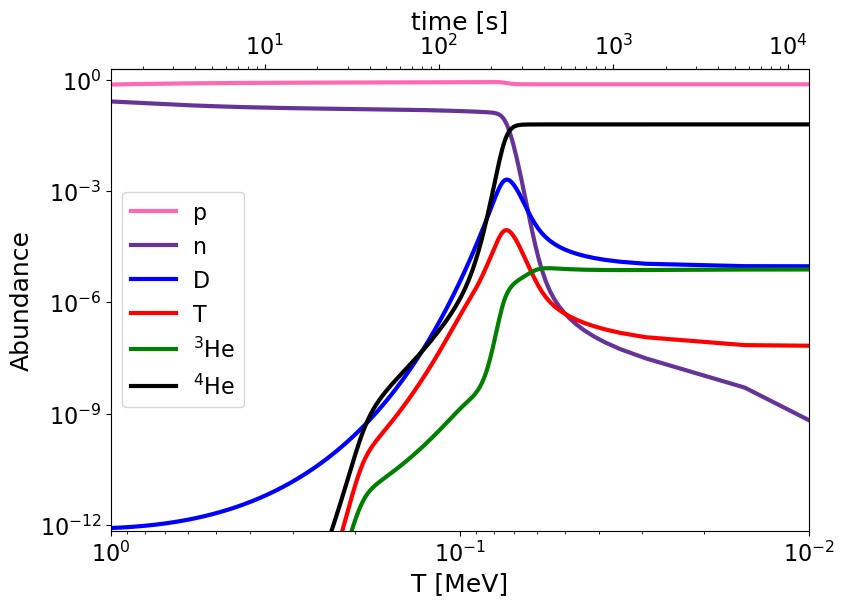

In [9]:
y_total = y_std

timeTemp = scipy.interpolate.interp1d(y_total[:,1]*hbar, y_total[:,0], kind='cubic')
def time_to_temp(t):
    return y_total[-1,0] * (t / y_total[-1,1]/hbar)**(-0.5)

tempTime = scipy.interpolate.interp1d(y_total[:,0],y_total[:,1]*hbar,  kind='cubic')
def temp_to_time(T):
    return y_total[-1,1]*hbar * (T / y_total[-1,0])**(-2)

fig, ax = plt.subplots(figsize=(9,6))
ax.loglog(y_total[:,0], y_total[:,3+nse.P_INDEX], color="hotpink", label="p", lw=3)
ax.loglog(y_total[:,0], y_total[:,3+nse.N_INDEX], color="rebeccapurple", label="n", lw=3)
ax.loglog(y_total[:,0], y_total[:,3+nse.H2_INDEX], color="blue", label="D", lw=3)
ax.loglog(y_total[:,0], y_total[:,3+nse.H3_INDEX], color="red", label="T", lw=3)
ax.loglog(y_total[:,0], y_total[:,3+nse.HE3_INDEX], color="green", label=r"${}^3$He", lw=3)
ax.loglog(y_total[:,0], y_total[:,3+nse.HE4_INDEX], color="black", label=r"${}^4$He", lw=3)
ax.legend(loc='center left', fontsize=16)

ax.set_xlabel("T [MeV]", fontsize=18)
ax.set_ylabel("Abundance", fontsize=18)
ax.set_ylim(0.7e-12, 2)
ax.set_xlim(1, 0.01)
plt.xticks(fontsize=16)
plt.yticks([1e-12, 1e-9, 1e-6, 1e-3, 1],fontsize=16)

timeax = ax.secondary_xaxis('top', functions=(temp_to_time, time_to_temp))
timeax.set_xlabel("time [s]", fontsize=18)
timeax.tick_params(axis='x', labelsize=16)

#plt.savefig("BBN.png", bbox_inches='tight')

/var/folders/9_/mvz7zy8s75d54b6716vd69695_lgwz/T/ipykernel_56563/465616748.py:5: RuntimeWarning: divide by zero encountered in power
  return y_total[-1,0] * (t / y_total[-1,1]/hbar)**(-0.5)


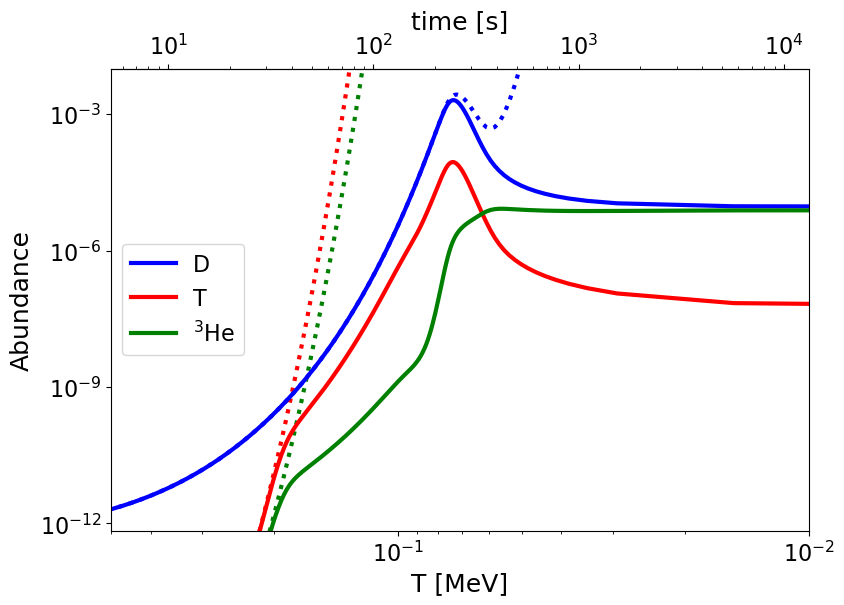

In [14]:
nseval=np.zeros((9,len(y_total[:,0])))
    
for i in range(len(nseval[0])):
    nseval[:,i] = nse.nse(y_total[i,0] , y_total[i,2] , y_total[i,3] , y_total[i,4],)

plot_index = np.where(y_total[:,0] > 0.04)[0]

fig, ax = plt.subplots(figsize=(9,6))
ax.loglog(y_total[plot_index,0], nseval[nse.H2_INDEX,plot_index], color="blue", ls=":", lw=3)

ax.loglog(y_total[plot_index,0], nseval[nse.H3_INDEX,plot_index], color="red", ls=":", lw=3)

ax.loglog(y_total[plot_index,0], nseval[nse.HE3_INDEX,plot_index], color="green", ls=":", lw=3)
ax.loglog(y_total[:,0], y_total[:,3+nse.H2_INDEX], color="blue", label="D", lw=3)
ax.loglog(y_total[:,0], y_total[:,3+nse.H3_INDEX], color="red", label="T", lw=3)
ax.loglog(y_total[:,0], y_total[:,3+nse.HE3_INDEX], color="green", label=r"${}^3$He", lw=3)


ax.legend(loc='center left', fontsize=16)
ax.set_ylim(0.7e-12, 1e-2)
ax.set_xlim(0.5, 0.01)
plt.xticks(fontsize=16)
plt.yticks([1e-12, 1e-9, 1e-6, 1e-3],fontsize=16)
plt.xlabel("T [MeV]", fontsize=18)
plt.ylabel("Abundance", fontsize=18)
timeax = ax.secondary_xaxis('top', functions=(temp_to_time, time_to_temp))
timeax.set_xlabel("time [s]", fontsize=18)
timeax.tick_params(axis='x', labelsize=16)

#plt.savefig("NSE.png", bbox_inches='tight')

/var/folders/9_/mvz7zy8s75d54b6716vd69695_lgwz/T/ipykernel_56563/465616748.py:5: RuntimeWarning: divide by zero encountered in power
  return y_total[-1,0] * (t / y_total[-1,1]/hbar)**(-0.5)


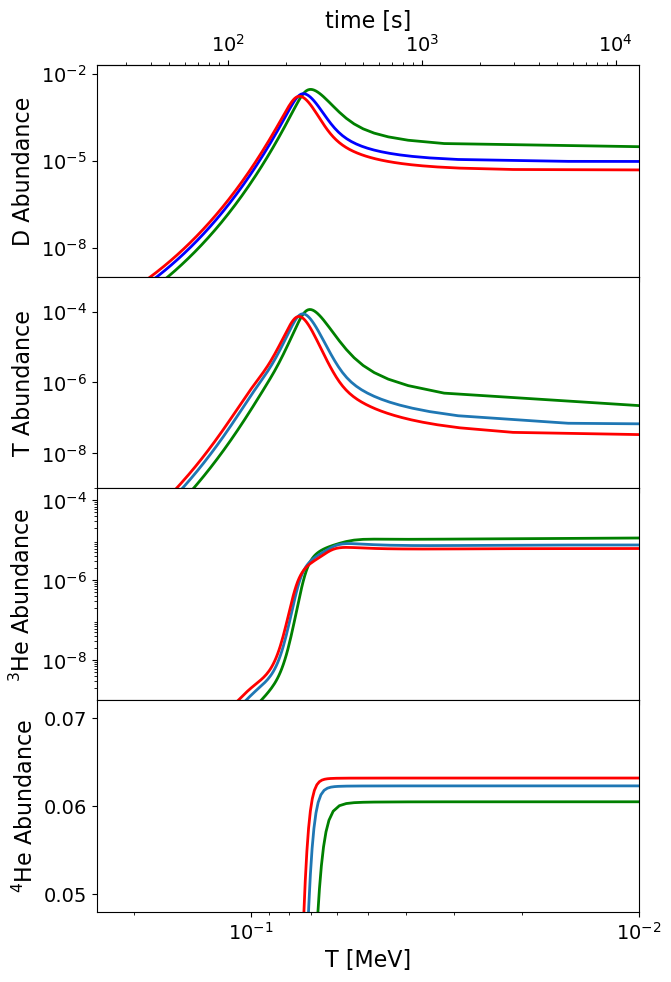

In [61]:
y_total = y_std
y_total_low = y_low
y_total_high = y_high

fig, ax = plt.subplots(4, 1, figsize=(7,11), sharex='col')
fig.subplots_adjust(hspace=0.0)

#for i in range(3):
#    ax[i].tick_params(axis='x', which='both', direction='inout', length=6)

ax[0].loglog(y_total_low[:,0], y_total_low[:,3+nse.H2_INDEX], color = "green", label=r"$\eta = 3 \times 10^{-10}$", lw=2)
ax[0].loglog(y_total[:,0], y_total[:,3+nse.H2_INDEX],color = "blue", label=r"$\eta = 6.1 \times 10^{-10}$", lw=2)
ax[0].loglog(y_total_high[:,0], y_total_high[:,3+nse.H2_INDEX], color = "red", label=r"$\eta = 9 \times 10^{-10}$", lw=2)
ax[0].set_xlim(0.25, 0.01)
ax[0].set_ylabel("D Abundance", fontsize=16)
ax[0].set_yticks([1e-8, 1e-5, 1e-2])
ax[0].tick_params(axis='y', labelsize=14)
ax[0].set_ylim(1e-9,2e-2)
#ax[0].legend(loc = "lower right", fontsize=14)

timeax = ax[0].secondary_xaxis('top', functions=(temp_to_time, time_to_temp))
timeax.set_xlabel("time [s]", fontsize=16)
timeax.tick_params(axis='x', labelsize=14)

ax[1].loglog(y_total_low[:,0], y_total_low[:,3+nse.H3_INDEX], color = "green", lw=2)
ax[1].loglog(y_total[:,0], y_total[:,3+nse.H3_INDEX], lw=2)
ax[1].loglog(y_total_high[:,0], y_total_high[:,3+nse.H3_INDEX], color = "red", lw=2)
ax[1].set_ylabel("T Abundance", fontsize=16)
ax[1].set_yticks([1e-8, 1e-6, 1e-4])
ax[1].set_ylim(1e-9,1e-3)
ax[1].tick_params(axis='y', labelsize=14)

ax[2].loglog(y_total_low[:,0], y_total_low[:,3+nse.HE3_INDEX], color = "green", lw=2)
ax[2].loglog(y_total[:,0], y_total[:,3+nse.HE3_INDEX], lw=2)
ax[2].loglog(y_total_high[:,0], y_total_high[:,3+nse.HE3_INDEX], color = "red", lw=2)
ax[2].set_ylabel(r"${}^3$He Abundance", fontsize=16)
ax[2].set_yticks([1e-8, 1e-6, 1e-4])
ax[2].set_ylim(1e-9,2e-4)
ax[2].tick_params(axis='y', labelsize=14)

ax[3].semilogx(y_total_low[:,0], y_total_low[:,3+nse.HE4_INDEX], color = "green", lw=2)
ax[3].semilogx(y_total[:,0], y_total[:,3+nse.HE4_INDEX], lw=2)
ax[3].semilogx(y_total_high[:,0], y_total_high[:,3+nse.HE4_INDEX], color = "red", lw=2)
ax[3].set_ylabel(r"${}^4$He Abundance", fontsize=16)
ax[3].set_yticks([0.05, 0.06, 0.07])
ax[3].set_ylim(0.048, 0.072)
ax[3].tick_params(axis='both', labelsize=14)
ax[3].set_xlabel("T [MeV]", fontsize=16)
plt.savefig("eta.png", bbox_inches="tight")

In [14]:
def a_total_y_tot_RMFK(eta_final):
    p = 4
    
    T0 = 15
    a0 = 1/T0
    t0 = 0
    eta0 = eta_final*(11/4)
    Yp0 = (1+(weak.Npntot(T0,a0))/(weak.Nnptot(T0,a0)) )**(-1)
    Yn0 = 1-Yp0

    y0 = der.depvar(T0, t0, eta0, nse.nse(T0, eta0, Yp0, Yn0))
    dx0=0.001

    N_step = 1000
    dN = 20

    x_final = 0.4

    a, y, dx, done = ODE.ODEOneRun(a0, y0, dx0, p, N_step, dN, x_final)
    print(done, y[-1,0])

    a1 = a[-1]
    T1 = y[-1, 0]
    t1 = y[-1, 1]
    eta1 = y[-1, 2]
    Y1 = der.depvar(T1,t1,eta1,nse.nse(T1,eta1,y[-1,3], y[-1,4]))
    dx1 = dx[-1]*0.001
    p = 5
    Nstep = 1000
    dN = 50
    x_final = 1000

    a2, y2, dx2, done = ODE.ODEOneRun(a1, Y1, dx1, p, Nstep, dN, x_final)
    print(done)
    for i in range(len(a)):
        A_nse = nse.nse(y[i,0], y[i,2], y[i,3],y[i,4])
        y[i,3:] = A_nse   

    a_total = np.concatenate((a[:-1],a2))   #creates an array of all the ind var values
    #len(a_total) = len(a)-1+len(a2)
    y_total = np.concatenate((y[:-1,:],y2),axis = 0) #creates a matrix of dep var values
    #y_total.shape is len(a_total) x 12

    print("Final eta = ", y_total[-1,2])

    return a_total, y_total

In [16]:
a_RMFK, y_RMFK = a_total_y_tot_RMFK(6.1e-10*6.1/3.544)

True 2.967283166786169
True
Final eta =  6.100396696992749e-10


([<matplotlib.axis.YTick at 0x16ab15430>,
 [Text(0, 1e-12, '$\\mathdefault{10^{-12}}$'),
  Text(0, 1e-09, '$\\mathdefault{10^{-9}}$'),
  Text(0, 1e-06, '$\\mathdefault{10^{-6}}$'),
  Text(0, 0.001, '$\\mathdefault{10^{-3}}$'),
  Text(0, 1.0, '$\\mathdefault{10^{0}}$')])

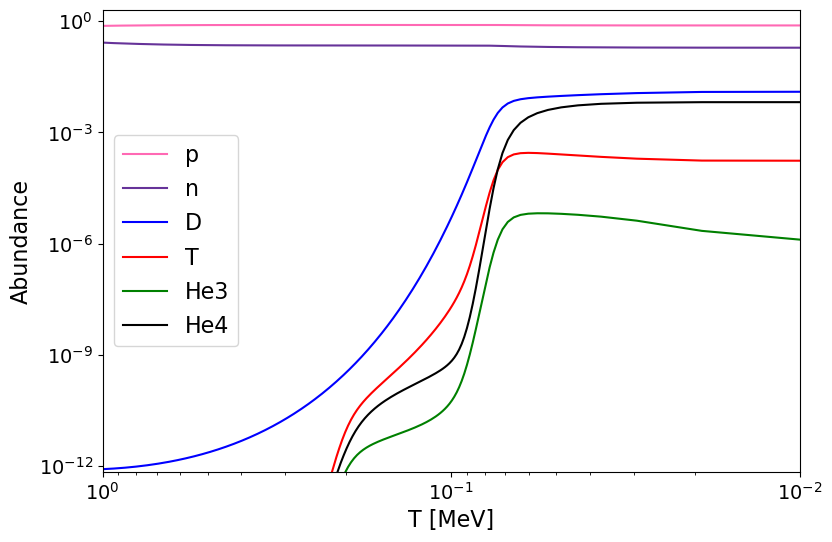

In [17]:
y_total = y_RMFK

fig, ax = plt.subplots(figsize=(9,6))
ax.loglog(y_total[:,0], y_total[:,3+nse.P_INDEX], color="hotpink", label="p")
ax.loglog(y_total[:,0], y_total[:,3+nse.N_INDEX], color="rebeccapurple", label="n")
ax.loglog(y_total[:,0], y_total[:,3+nse.H2_INDEX], color="blue", label="D")
ax.loglog(y_total[:,0], y_total[:,3+nse.H3_INDEX], color="red", label="T")
ax.loglog(y_total[:,0], y_total[:,3+nse.HE3_INDEX], color="green", label="He3")
ax.loglog(y_total[:,0], y_total[:,3+nse.HE4_INDEX], color="black", label="He4")
ax.legend(loc='center left', fontsize=16)

ax.set_xlabel("T [MeV]", fontsize=16)
ax.set_ylabel("Abundance", fontsize=16)
ax.set_ylim(0.7e-12, 2)
ax.set_xlim(1, 0.01)
plt.xticks(fontsize=14)
plt.yticks([1e-12, 1e-9, 1e-6, 1e-3, 1],fontsize=14)

0.06227449660404613 0.006534237713841742


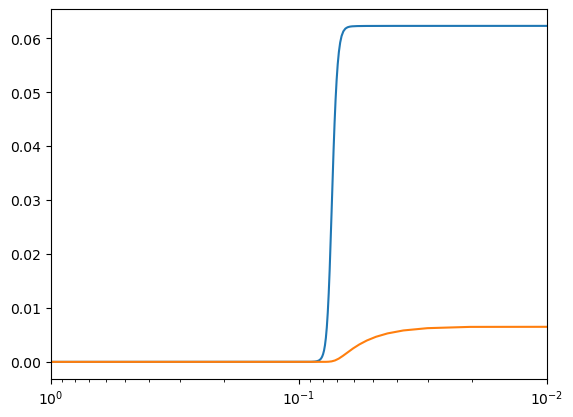

In [26]:
plt.semilogx(y_std[:,0], y_std[:,3+nse.HE4_INDEX])
plt.semilogx(y_RMFK[:,0], y_RMFK[:,3+nse.HE4_INDEX])
plt.xlim(1, 0.01)
print(y_std[-1,3+nse.HE4_INDEX], y_RMFK[-1,3+nse.HE4_INDEX])

9.188815357795807e-06 0.012751050476422485


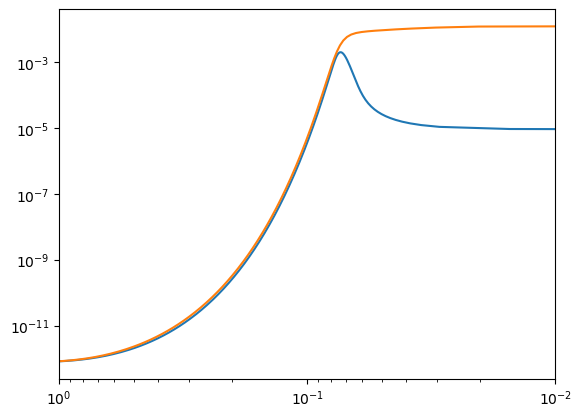

In [44]:
plt.loglog(y_std[:,0], y_std[:,3+nse.H2_INDEX])
plt.loglog(y_RMFK[:,0], y_RMFK[:,3+nse.H2_INDEX])
plt.xlim(1, 0.01)
print(y_std[-1,3+nse.H2_INDEX], y_RMFK[-1,3+nse.H2_INDEX])

(20, 0.01)

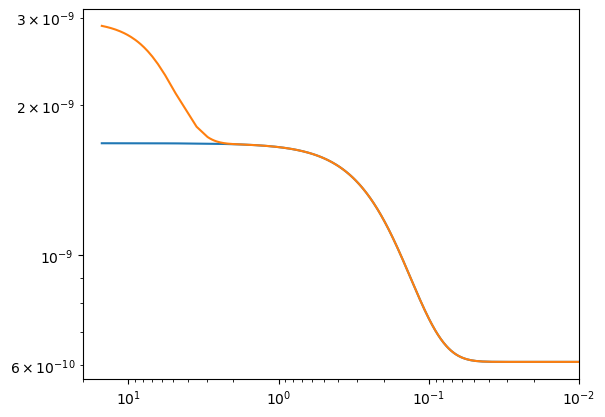

In [50]:
plt.loglog(y_std[:,0], y_std[:,2])
plt.loglog(y_RMFK[:,0], y_RMFK[:,2])
plt.xlim(20, 0.01)

(1, 0.01)

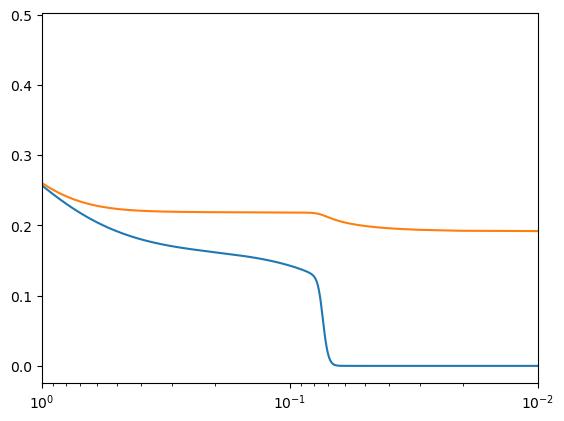

In [68]:
plt.semilogx(y_std[:,0], y_std[:,3+nse.N_INDEX])
plt.semilogx(y_RMFK[:,0], y_RMFK[:,3+nse.N_INDEX])
plt.xlim(1, 0.01)

In [56]:
nseval_RMFK=np.zeros((9,len(a_RMFK)))
    
for i in range(len(a_RMFK)):
    nseval_RMFK[:,i] = nse.nse(y_RMFK[i,0] , y_RMFK[i,2] , y_RMFK[i,3] , y_RMFK[i,4])

([<matplotlib.axis.YTick at 0x32f7b44a0>,
 [Text(0, 1e-12, '$\\mathdefault{10^{-12}}$'),
  Text(0, 1e-09, '$\\mathdefault{10^{-9}}$'),
  Text(0, 1e-06, '$\\mathdefault{10^{-6}}$'),
  Text(0, 0.001, '$\\mathdefault{10^{-3}}$'),
  Text(0, 1.0, '$\\mathdefault{10^{0}}$')])

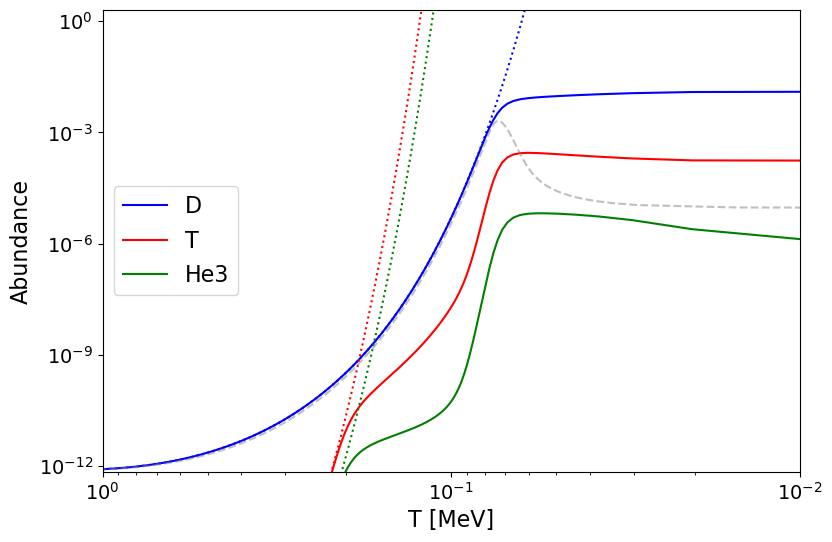

In [66]:
y_total = y_RMFK

fig, ax = plt.subplots(figsize=(9,6))
ax.loglog(y_total[:,0], y_total[:,3+nse.H2_INDEX], color="blue", label="D")
ax.loglog(y_total[:,0], y_total[:,3+nse.H3_INDEX], color="red", label="T")
ax.loglog(y_total[:,0], y_total[:,3+nse.HE3_INDEX], color="green", label="He3")
ax.legend(loc='center left', fontsize=16)

ax.loglog(y_total[:,0], nseval_RMFK[nse.H2_INDEX,:], color='b', ls=":")
ax.loglog(y_total[:,0], nseval_RMFK[nse.H3_INDEX,:], color='r', ls=":")
ax.loglog(y_total[:,0], nseval_RMFK[nse.HE3_INDEX,:], color='g', ls=":")

ax.loglog(y_std[:,0], y_std[:,3+nse.H2_INDEX], color="0.50", alpha=0.5, ls="--")

ax.set_xlabel("T [MeV]", fontsize=16)
ax.set_ylabel("Abundance", fontsize=16)
ax.set_ylim(0.7e-12, 2)
ax.set_xlim(1, 0.01)
plt.xticks(fontsize=14)
plt.yticks([1e-12, 1e-9, 1e-6, 1e-3, 1],fontsize=14)

In [53]:
eta_CMB = 6.1e-10
def intro_heat(Q0, a0=1):
    a_tot, y_tot = a_total_y_tot(eta_CMB, Q0, a0, 1, 1, 0)

    if (np.abs(1 - y_tot[-1,2] / eta_CMB) < 0.01):
        return a_tot, y_tot

    a_total, y_total = a_total_y_tot(eta_CMB * eta_CMB / y_tot[-1,2], Q0, a0, 1, 1, 0)

    return a_total, y_total

In [60]:
%%time
a_warm, y_warm = intro_heat(0.3, 1)

a_hot, y_hot = intro_heat(0.006, 6)


True
True
True
True
True
True
True
True
CPU times: user 35.6 s, sys: 3.41 s, total: 39 s
Wall time: 35.7 s


/var/folders/9_/mvz7zy8s75d54b6716vd69695_lgwz/T/ipykernel_83903/465616748.py:5: RuntimeWarning: divide by zero encountered in power
  return y_total[-1,0] * (t / y_total[-1,1]/hbar)**(-0.5)


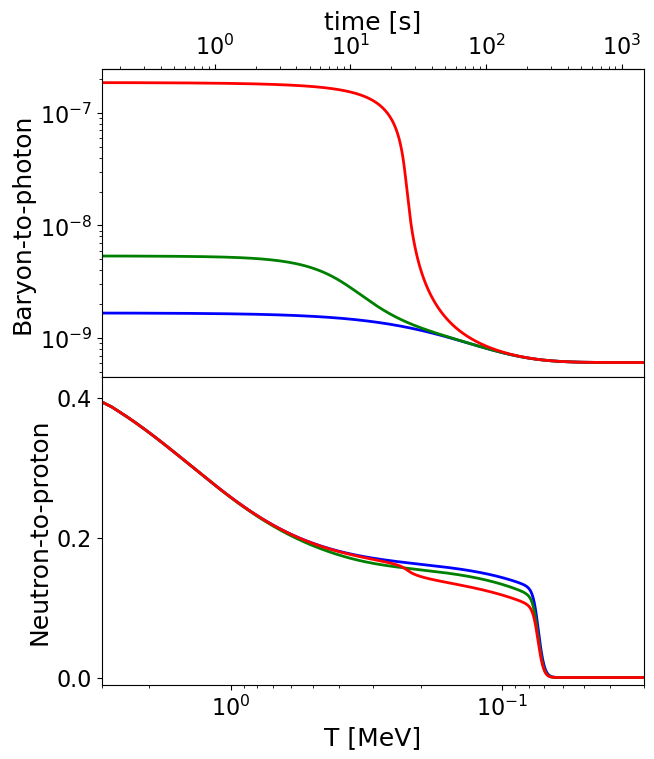

In [61]:
y_total = y_std
y_total_Q3 = y_warm
y_total_Q6 = y_hot

fig, ax = plt.subplots(2, 1, figsize=(7,8), sharex='col')
fig.subplots_adjust(hspace=0)
ax[0].loglog(y_total[:,0], y_total[:,2], color="blue", label="standard", lw=2)
ax[0].loglog(y_total_Q3[:,0], y_total_Q3[:,2], color="green", label="Model 1", lw=2)
ax[0].loglog(y_total_Q6[:,0], y_total_Q6[:,2], color="red", label="Model 2", lw=2)
ax[0].set_ylabel("Baryon-to-photon", fontsize=18)
ax[0].tick_params(axis='y', labelsize=16)
ax[0].set_xlim(3, 3e-2)
#ax[0].legend(loc = "upper right", fontsize=14)

timeax = ax[0].secondary_xaxis('top', functions=(temp_to_time, time_to_temp))
timeax.set_xlabel("time [s]", fontsize=18)
timeax.tick_params(axis='x', labelsize=16)

ax[1].semilogx(y_total[:,0], y_total[:,3+nse.N_INDEX], c="blue", lw=2)
ax[1].semilogx(y_total_Q3[:,0], y_total_Q3[:,3+nse.N_INDEX], c="green", lw=2)
ax[1].semilogx(y_total_Q6[:,0], y_total_Q6[:,3+nse.N_INDEX], c="red", lw=2)
ax[1].set_ylabel("Neutron-to-proton", fontsize=18)
ax[1].tick_params(axis='both', labelsize=16)
ax[1].set_xlabel("T [MeV]", fontsize=18)
ax[1].set_ylim([-0.01,0.43])
ax[1].set_yticks([0, 0.2, 0.4])

plt.savefig("Qmodel.png", bbox_inches='tight')

/var/folders/9_/mvz7zy8s75d54b6716vd69695_lgwz/T/ipykernel_83903/465616748.py:5: RuntimeWarning: divide by zero encountered in power
  return y_total[-1,0] * (t / y_total[-1,1]/hbar)**(-0.5)


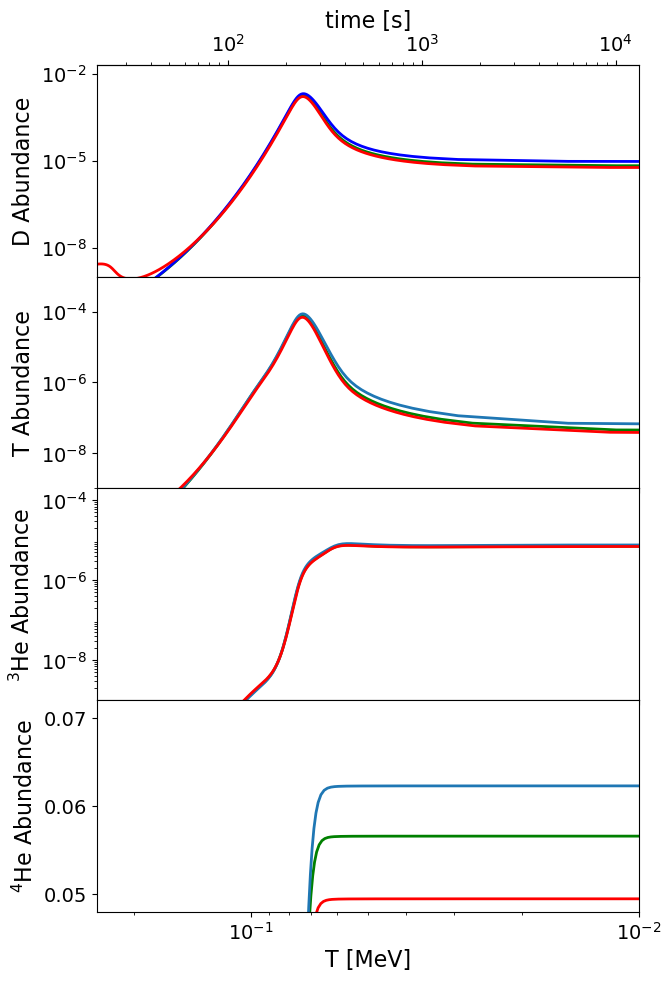

In [64]:
y_total = y_std
y_total_low = y_warm
y_total_high = y_hot

fig, ax = plt.subplots(4, 1, figsize=(7,11), sharex='col')
fig.subplots_adjust(hspace=0.0)

#for i in range(3):
#    ax[i].tick_params(axis='x', which='both', direction='inout', length=6)

ax[0].loglog(y_total_low[:,0], y_total_low[:,3+nse.H2_INDEX], color = "green", label=r"$\eta = 3 \times 10^{-10}$", lw=2)
ax[0].loglog(y_total[:,0], y_total[:,3+nse.H2_INDEX],color = "blue", label=r"$\eta = 6.1 \times 10^{-10}$", lw=2)
ax[0].loglog(y_total_high[:,0], y_total_high[:,3+nse.H2_INDEX], color = "red", label=r"$\eta = 9 \times 10^{-10}$", lw=2)
ax[0].set_xlim(0.25, 0.01)
ax[0].set_ylabel("D Abundance", fontsize=16)
ax[0].set_yticks([1e-8, 1e-5, 1e-2])
ax[0].tick_params(axis='y', labelsize=14)
ax[0].set_ylim(1e-9,2e-2)
#ax[0].legend(loc = "lower right", fontsize=14)

timeax = ax[0].secondary_xaxis('top', functions=(temp_to_time, time_to_temp))
timeax.set_xlabel("time [s]", fontsize=16)
timeax.tick_params(axis='x', labelsize=14)

ax[1].loglog(y_total_low[:,0], y_total_low[:,3+nse.H3_INDEX], color = "green", lw=2)
ax[1].loglog(y_total[:,0], y_total[:,3+nse.H3_INDEX], lw=2)
ax[1].loglog(y_total_high[:,0], y_total_high[:,3+nse.H3_INDEX], color = "red", lw=2)
ax[1].set_ylabel("T Abundance", fontsize=16)
ax[1].set_yticks([1e-8, 1e-6, 1e-4])
ax[1].set_ylim(1e-9,1e-3)
ax[1].tick_params(axis='y', labelsize=14)

ax[2].loglog(y_total_low[:,0], y_total_low[:,3+nse.HE3_INDEX], color = "green", lw=2)
ax[2].loglog(y_total[:,0], y_total[:,3+nse.HE3_INDEX], lw=2)
ax[2].loglog(y_total_high[:,0], y_total_high[:,3+nse.HE3_INDEX], color = "red", lw=2)
ax[2].set_ylabel(r"${}^3$He Abundance", fontsize=16)
ax[2].set_yticks([1e-8, 1e-6, 1e-4])
ax[2].set_ylim(1e-9,2e-4)
ax[2].tick_params(axis='y', labelsize=14)

ax[3].semilogx(y_total_low[:,0], y_total_low[:,3+nse.HE4_INDEX], color = "green", lw=2)
ax[3].semilogx(y_total[:,0], y_total[:,3+nse.HE4_INDEX], lw=2)
ax[3].semilogx(y_total_high[:,0], y_total_high[:,3+nse.HE4_INDEX], color = "red", lw=2)
ax[3].set_ylabel(r"${}^4$He Abundance", fontsize=16)
ax[3].set_yticks([0.05, 0.06, 0.07])
ax[3].set_ylim(0.048, 0.072)
ax[3].tick_params(axis='both', labelsize=14)
ax[3].set_xlabel("T [MeV]", fontsize=16)

plt.savefig("QBBN.png", bbox_inches='tight')

In [18]:
weak.N(1, 1)

3.099137921852444e-25

In [20]:
weak.N(0.1, 0.1)

3.726566330334503e-25

In [22]:
import decay_results as dec

In [29]:
dec.fitting(1/0.01, dec.NP_RATE_INDEX)

4.422333260302081e-16

In [35]:
dec.fitting(100, dec.PN_RATE_INDEX)

4.054030618146907e-16

In [33]:
a_RMFK

array([6.66666667e-02, 6.72464482e-02, 6.78435525e-02, 6.84622002e-02,
       6.91038884e-02, 6.97688632e-02, 7.04643485e-02, 7.11771933e-02,
       7.19270823e-02, 7.27145827e-02, 7.35205268e-02, 7.43736441e-02,
       7.52752404e-02, 7.62086521e-02, 7.71820945e-02, 7.82177123e-02,
       7.93172658e-02, 8.04556164e-02, 8.16771861e-02, 8.29836823e-02,
       8.43557049e-02, 8.58261336e-02, 8.74146100e-02, 8.90924148e-02,
       9.09322604e-02, 9.29252783e-02, 9.50862614e-02, 9.74306349e-02,
       1.00044272e-01, 1.02962469e-01, 1.06227755e-01, 1.09862540e-01,
       1.14079437e-01, 1.19007566e-01, 1.24832405e-01, 1.31828317e-01,
       1.40437613e-01, 1.51799090e-01, 1.67140608e-01, 1.89774030e-01,
       2.29558618e-01, 3.32899706e-01, 4.00000000e-01, 4.07434456e-01,
       4.15129718e-01, 4.22971149e-01, 4.30953644e-01, 4.39088599e-01,
       4.47390045e-01, 4.55836386e-01, 4.64466101e-01, 4.73219487e-01,
       4.82164181e-01, 4.91288440e-01, 5.00550420e-01, 5.10004786e-01,
      

/var/folders/9_/mvz7zy8s75d54b6716vd69695_lgwz/T/ipykernel_83903/465616748.py:5: RuntimeWarning: divide by zero encountered in power
  return y_total[-1,0] * (t / y_total[-1,1]/hbar)**(-0.5)


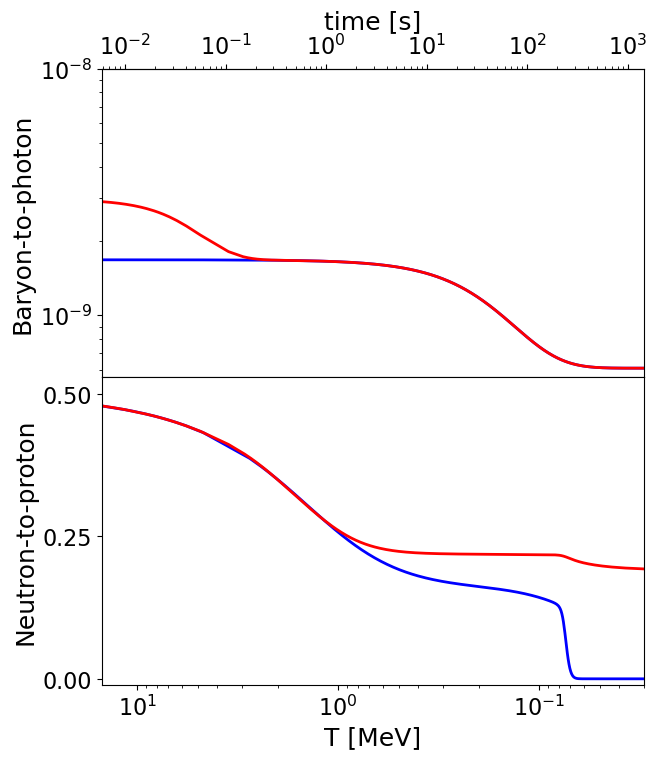

In [38]:
y_total = y_std
y_total_Q6 = y_RMFK

fig, ax = plt.subplots(2, 1, figsize=(7,8), sharex='col')
fig.subplots_adjust(hspace=0)
ax[0].loglog(y_total[:,0], y_total[:,2], color="blue", label="standard", lw=2)
ax[0].loglog(y_total_Q6[:,0], y_total_Q6[:,2], color="red", label="Model 2", lw=2)
ax[0].set_ylabel("Baryon-to-photon", fontsize=18)
#ax[0].tick_params(axis='y', labelsize=16)
ax[0].set_yticks([1e-9, 1e-8])
ax[0].tick_params(axis='y', labelsize=16)
ax[0].set_xlim(15, 3e-2)
#ax[0].legend(loc = "upper right", fontsize=14)

timeax = ax[0].secondary_xaxis('top', functions=(temp_to_time, time_to_temp))
timeax.set_xlabel("time [s]", fontsize=18)
timeax.tick_params(axis='x', labelsize=16)

ax[1].semilogx(y_total[:,0], y_total[:,3+nse.N_INDEX], c="blue", lw=2)
ax[1].semilogx(y_total_Q6[:,0], y_total_Q6[:,3+nse.N_INDEX], c="red", lw=2)
ax[1].set_ylabel("Neutron-to-proton", fontsize=18)
ax[1].tick_params(axis='both', labelsize=16)
ax[1].set_xlabel("T [MeV]", fontsize=18)
ax[1].set_ylim([-0.01,0.53])
ax[1].set_yticks([0, 0.25, 0.5])

plt.savefig("RMFK_model.png", bbox_inches='tight')

/var/folders/9_/mvz7zy8s75d54b6716vd69695_lgwz/T/ipykernel_83903/465616748.py:5: RuntimeWarning: divide by zero encountered in power
  return y_total[-1,0] * (t / y_total[-1,1]/hbar)**(-0.5)


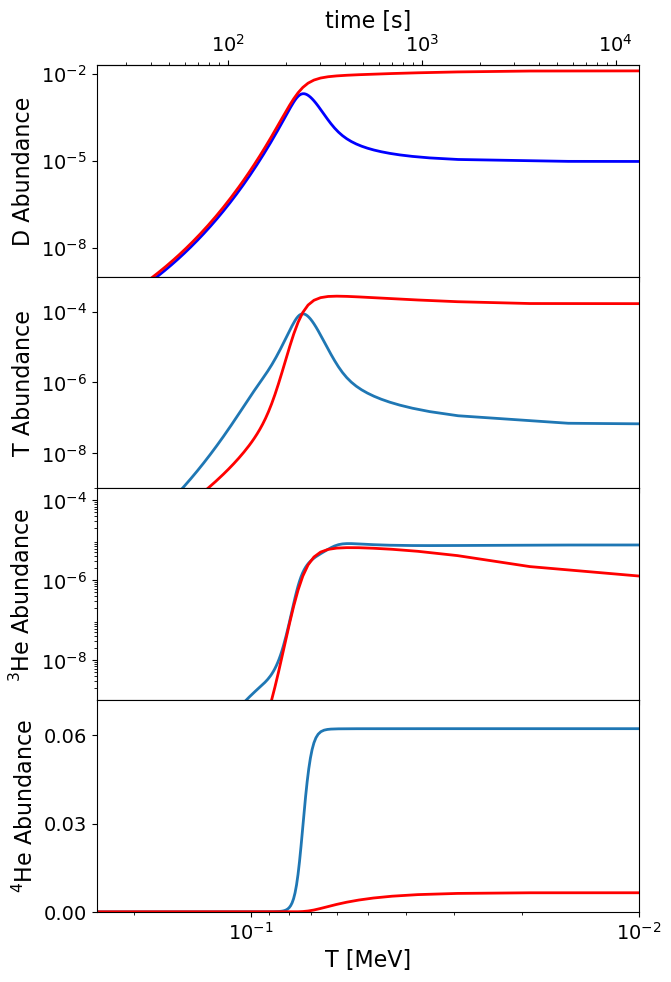

In [48]:
y_total = y_std
y_total_high = y_RMFK

fig, ax = plt.subplots(4, 1, figsize=(7,11), sharex='col')
fig.subplots_adjust(hspace=0.0)

#for i in range(3):
#    ax[i].tick_params(axis='x', which='both', direction='inout', length=6)

ax[0].loglog(y_total[:,0], y_total[:,3+nse.H2_INDEX],color = "blue", label=r"$\eta = 6.1 \times 10^{-10}$", lw=2)
ax[0].loglog(y_total_high[:,0], y_total_high[:,3+nse.H2_INDEX], color = "red", label=r"$\eta = 9 \times 10^{-10}$", lw=2)
ax[0].set_xlim(0.25, 0.01)
ax[0].set_ylabel("D Abundance", fontsize=16)
ax[0].set_yticks([1e-8, 1e-5, 1e-2])
ax[0].tick_params(axis='y', labelsize=14)
ax[0].set_ylim(1e-9,2e-2)
#ax[0].legend(loc = "lower right", fontsize=14)

timeax = ax[0].secondary_xaxis('top', functions=(temp_to_time, time_to_temp))
timeax.set_xlabel("time [s]", fontsize=16)
timeax.tick_params(axis='x', labelsize=14)

ax[1].loglog(y_total[:,0], y_total[:,3+nse.H3_INDEX], lw=2)
ax[1].loglog(y_total_high[:,0], y_total_high[:,3+nse.H3_INDEX], color = "red", lw=2)
ax[1].set_ylabel("T Abundance", fontsize=16)
ax[1].set_yticks([1e-8, 1e-6, 1e-4])
ax[1].set_ylim(1e-9,1e-3)
ax[1].tick_params(axis='y', labelsize=14)

ax[2].loglog(y_total[:,0], y_total[:,3+nse.HE3_INDEX], lw=2)
ax[2].loglog(y_total_high[:,0], y_total_high[:,3+nse.HE3_INDEX], color = "red", lw=2)
ax[2].set_ylabel(r"${}^3$He Abundance", fontsize=16)
ax[2].set_yticks([1e-8, 1e-6, 1e-4])
ax[2].set_ylim(1e-9,2e-4)
ax[2].tick_params(axis='y', labelsize=14)

ax[3].semilogx(y_total[:,0], y_total[:,3+nse.HE4_INDEX], lw=2)
ax[3].semilogx(y_total_high[:,0], y_total_high[:,3+nse.HE4_INDEX], color = "red", lw=2)
ax[3].set_ylabel(r"${}^4$He Abundance", fontsize=16)
ax[3].set_ylim(0.0, 0.072)
ax[3].set_yticks([0, 0.03, 0.06])
ax[3].tick_params(axis='both', labelsize=14)
ax[3].set_xlabel("T [MeV]", fontsize=16)

plt.savefig("RMFK_BBN.png", bbox_inches='tight')